In [ ]:
import os
import pandas as pd
import json
import matplotlib.pyplot as plt


Cloning into 'narrativeqa'...
remote: Enumerating objects: 25, done.
remote: Total 25 (delta 0), reused 0 (delta 0), pack-reused 25 (from 1)
Receiving objects: 100% (25/25), 4.88 MiB | 7.44 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [ ]:
# Clone NarrativeQA repo if not present
repo_dir = "narrativeqa"
if not os.path.exists(repo_dir):
    !git clone https://github.com/google-deepmind/narrativeqa.git $repo_dir

In [ ]:
# read and get data

# Assumes repo_dir = 'narrativeqa' and CSVs exist
repo_dir = "narrativeqa"

docs_path = os.path.join(repo_dir, "documents.csv")
qaps_path = os.path.join(repo_dir, "qaps.csv")
summaries_path = os.path.join(repo_dir, "third_party", "wikipedia", "summaries.csv")

docs = pd.read_csv(docs_path)
qaps = pd.read_csv(qaps_path)
summaries = pd.read_csv(summaries_path)

# 1) Keep only movie documents
movie_docs = docs[docs["kind"] == "movie"]
movie_ids = set(movie_docs["document_id"])

# 2) Filter QAs and summaries to those movies
qaps_movie = qaps[qaps["document_id"].isin(movie_ids)]
summaries_movie = summaries[summaries["document_id"].isin(movie_ids)]

# 3) Merge movie QAs with summaries on document_id
qa_with_summ = qaps_movie.merge(
    summaries_movie[["document_id", "summary"]],
    on="document_id",
    how="inner",
)

# 4) Keep only rows whose ORIGINAL summary length is <= 3000 characters
max_len = 3000
qa_with_summ = qa_with_summ[qa_with_summ["summary"].str.len() <= max_len]

# 5) Build prompts and responses
def build_prompt(row):
    return (
        f"Summary (context):\n{row['summary']}\n\n"
        f"Question:\n{row['question']}\n\n"
        "Answer:"
    )

qa_with_summ["prompt"] = qa_with_summ.apply(build_prompt, axis=1)
qa_with_summ["response"] = qa_with_summ["answer1"].fillna(qa_with_summ["answer2"])

# 6) Drop rows where response is still missing
qa_with_summ = qa_with_summ.dropna(subset=["response"])

# 7) Sample up to 1000 examples
num_samples = min(1000, len(qa_with_summ))
qa_samples = qa_with_summ.sample(num_samples, random_state=42).reset_index(drop=True)

print("Total MOVIE QA with summaries (<=3000 chars):", len(qa_with_summ))
print("Using samples:", len(qa_samples))
qa_samples[["prompt", "response"]].head()

Total MOVIE QA with summaries (<=3000 chars): 4148
Using samples: 1000


,prompt,response
0,Summary (context):\n Marty Piletti (Ernest Bor...,BUTCHER
1,Summary (context):\n The film explores several...,"Cindy's ex-boyfriend, Bobby."
2,"Summary (context):\n In 1976, in South Africa ...",Ben trusts the police too much to help.
3,"Summary (context):\n Aging gangster Benjamin ""...",after the street boss of the Bonanno family is...
4,Summary (context):\n The memories of an unname...,His was a thief.


In [ ]:
# save data
output_path = "data/narrativeqa_movies_lora_train_1000.jsonl"

with open(output_path, "w") as f:
    for _, row in qa_samples.iterrows():
        record = {
            "prompt": row["prompt"],
            "response": row["response"],
        }
        f.write(json.dumps(record) + "\n")

print("Saved", len(qa_samples), "movie examples to", output_path)

Saved 1000 movie examples to narrativeqa_movies_lora_train_1000.jsonl


Prompt length (chars) stats:
count    1000.000000
mean     2336.304000
std       520.829543
min      1190.000000
25%      1855.750000
50%      2457.000000
75%      2768.750000
max      3118.000000
Name: prompt_len_chars, dtype: float64


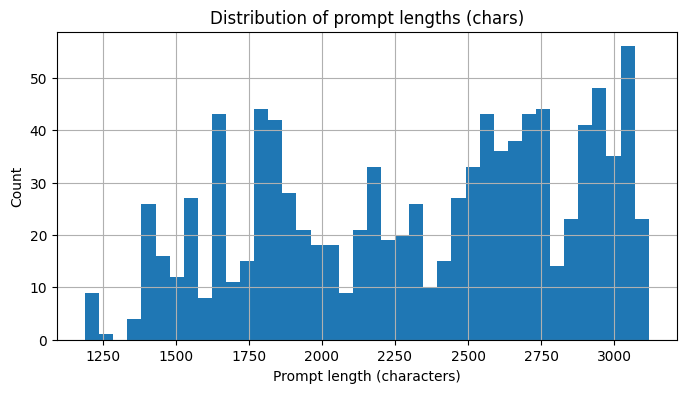

In [ ]:
# data distribution
# Length in characters
qa_samples["prompt_len_chars"] = qa_samples["prompt"].str.len()
print("Prompt length (chars) stats:")
print(qa_samples["prompt_len_chars"].describe())

plt.figure(figsize=(8, 4))
qa_samples["prompt_len_chars"].hist(bins=40)
plt.xlabel("Prompt length (characters)")
plt.ylabel("Count")
plt.title("Distribution of prompt lengths (chars)")
plt.show()